In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')


np.random.seed(42)

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Load the preprocessed data from Power BI
df = pd.read_csv('Dataset1.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())


Dataset Shape: (2198, 33)

First few rows:
     ID  Year_Birth   Education Marital_Status  Income  Kidhome  Teenhome  \
0  1386        1967  Graduation       Together   32474        1         1   
1  2795        1958      Master         Single   30523        2         1   
2   868        1966  Graduation        Married   44794        0         1   
3  7264        1978    2n Cycle         Single   52195        2         1   
4  2936        1982      Master       Together   23661        1         0   

  Dt_Customer  Recency  MntWines  ...  AcceptedCmp1  AcceptedCmp2  Complain  \
0   11-May-14        0        10  ...             0             0         0   
1   01-Jul-13        0         5  ...             0             0         0   
2   08-Jun-14       99        54  ...             0             0         0   
3   12-May-14        2        12  ...             0             0         0   
4   04-Dec-13       46        18  ...             0             0         0   

   Z_CostContact  Z

In [3]:
# Explore the data
print("Data Info:")
print(df.info())
print("\n" + "="*80)
print("Basic Statistics:")
print(df.describe())


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2198 entries, 0 to 2197
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2198 non-null   int64 
 1   Year_Birth           2198 non-null   int64 
 2   Education            2198 non-null   object
 3   Marital_Status       2198 non-null   object
 4   Income               2198 non-null   int64 
 5   Kidhome              2198 non-null   int64 
 6   Teenhome             2198 non-null   int64 
 7   Dt_Customer          2198 non-null   object
 8   Recency              2198 non-null   int64 
 9   MntWines             2198 non-null   int64 
 10  MntFruits            2198 non-null   int64 
 11  MntMeatProducts      2198 non-null   int64 
 12  MntFishProducts      2198 non-null   int64 
 13  MntSweetProducts     2198 non-null   int64 
 14  MntGoldProds         2198 non-null   int64 
 15  NumDealsPurchases    2198 non-null   int64 


In [4]:
# Feature Selection for Clustering
print("="*80)
print("FEATURE SELECTION")
print("="*80)

# Defined features to use for clustering
clustering_features = [
    # Demographics
    'Age',
    'Income',
    'Kidhome',
    'Teenhome',
    
    # Spending behavior
    'Total Spending',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    
    # Purchase channels
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth',
    
    # Engagement
    'Recency',
    
    # Campaign response 
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5',
    'Response',
    'Complain'
]

# Check which features are actually present in the dataframe
available_features = [f for f in clustering_features if f in df.columns]
missing_features = [f for f in clustering_features if f not in df.columns]

print(f"\n✓ Features available for clustering: {len(available_features)}")
for i, feature in enumerate(available_features, 1):
    print(f"  {i}. {feature}")

if missing_features:
    print(f"\n⚠ Missing features (will be skipped): {missing_features}")

# Extract feature matrix
X = df[available_features].values

# Check for missing values
if np.isnan(X).any():
    print("\n⚠ Warning: Found NaN values. Filling with column means...")
    col_mean = np.nanmean(X, axis=0)
    inds = np.where(np.isnan(X))
    X[inds] = np.take(col_mean, inds[1])

print(f"\n✓ Feature matrix shape: {X.shape}")
print(f"  (Rows: {X.shape[0]} customers, Columns: {X.shape[1]} features)")
print("="*80)


FEATURE SELECTION

✓ Features available for clustering: 24
  1. Age
  2. Income
  3. Kidhome
  4. Teenhome
  5. Total Spending
  6. MntWines
  7. MntFruits
  8. MntMeatProducts
  9. MntFishProducts
  10. MntSweetProducts
  11. MntGoldProds
  12. NumDealsPurchases
  13. NumWebPurchases
  14. NumCatalogPurchases
  15. NumStorePurchases
  16. NumWebVisitsMonth
  17. Recency
  18. AcceptedCmp1
  19. AcceptedCmp2
  20. AcceptedCmp3
  21. AcceptedCmp4
  22. AcceptedCmp5
  23. Response
  24. Complain

✓ Feature matrix shape: (2198, 24)
  (Rows: 2198 customers, Columns: 24 features)


In [5]:
# Feature Scaling (Essential for K-Means)
# K-Means is sensitive to scale, so we standardize features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaling complete.")
print(f"Scaled data shape: {X_scaled.shape}")
print(f"\nMean of first 5 scaled features: {X_scaled.mean(axis=0)[:5]}")  # Should be ~0
print(f"Std of first 5 scaled features: {X_scaled.std(axis=0)[:5]}")     # Should be ~1


Data scaling complete.
Scaled data shape: (2198, 24)

Mean of first 5 scaled features: [-1.93960710e-16 -1.29307140e-16 -3.87921421e-17  5.17228561e-17
 -1.29307140e-17]
Std of first 5 scaled features: [1. 1. 1. 1. 1.]


In [6]:
class KMeansFromScratch:
    """
    K-Means clustering algorithm implemented from scratch
    """
    
    def __init__(self, k=3, max_iters=300, tol=1e-4, random_state=42):
        """
        Initialize K-Means algorithm
        
        Parameters:
        -----------
        k : int
            Number of clusters
        max_iters : int
            Maximum number of iterations
        tol : float
            Tolerance for convergence (change in centroids)
        random_state : int
            Random seed for reproducibility
        """
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels = None
        self.inertia = None
        self.n_iters = 0
    
    def _initialize_centroids(self, X):
        """
        Initialize centroids using k-means++ algorithm for better initial placement
        """
        np.random.seed(self.random_state)
        n_samples = X.shape[0]
        
        # Choose first centroid randomly
        centroids = [X[np.random.randint(n_samples)]]
        
        # Choose remaining centroids
        for _ in range(1, self.k):
            # Calculate distances from each point to nearest centroid
            distances = np.array([min([np.linalg.norm(x - c)**2 for c in centroids]) 
                                  for x in X])
            
            # Choose next centroid with probability proportional to distance squared
            probabilities = distances / distances.sum()
            cumulative_probs = probabilities.cumsum()
            r = np.random.rand()
            
            for j, p in enumerate(cumulative_probs):
                if r < p:
                    centroids.append(X[j])
                    break
                    
        return np.array(centroids)
    
    def _assign_clusters(self, X):
        """
        Assign each point to the nearest centroid
        """
        distances = np.zeros((X.shape[0], self.k))
        
        # Calculate distance from each point to each centroid
        for i, centroid in enumerate(self.centroids):
            distances[:, i] = np.linalg.norm(X - centroid, axis=1)
        
        # Assign to nearest centroid
        return np.argmin(distances, axis=1)
    
    def _update_centroids(self, X, labels):
        """
        Update centroids as the mean of all points in each cluster
        """
        new_centroids = np.zeros((self.k, X.shape[1]))
        
        for i in range(self.k):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                new_centroids[i] = cluster_points.mean(axis=0)
            else:
                # If cluster is empty, reinitialize randomly
                new_centroids[i] = X[np.random.randint(X.shape[0])]
        
        return new_centroids
    
    def _calculate_inertia(self, X, labels):
        """
        Calculate within-cluster sum of squares (inertia)
        """
        inertia = 0
        for i in range(self.k):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                inertia += np.sum((cluster_points - self.centroids[i])**2)
        return inertia
    
    def fit(self, X):
        """
        Fit K-Means clustering to data
        """
        # Initialize centroids
        self.centroids = self._initialize_centroids(X)
        
        # Iterate until convergence or max iterations
        for iteration in range(self.max_iters):
            # Assign clusters
            old_centroids = self.centroids.copy()
            self.labels = self._assign_clusters(X)
            
            # Update centroids
            self.centroids = self._update_centroids(X, self.labels)
            
            # Check for convergence
            centroid_shift = np.linalg.norm(self.centroids - old_centroids)
            
            if centroid_shift < self.tol:
                self.n_iters = iteration + 1
                break
        
        # Calculate final inertia
        self.inertia = self._calculate_inertia(X, self.labels)
        
        if iteration == self.max_iters - 1:
            self.n_iters = self.max_iters
            
        return self
    
    def predict(self, X):
        """
        Predict cluster labels for new data
        """
        return self._assign_clusters(X)

print("K-Means algorithm implementation complete!")

K-Means algorithm implementation complete!


In [7]:
# Test the implementation with a simple example
print("Testing K-Means implementation with k=3...")
test_kmeans = KMeansFromScratch(k=3, random_state=42)
test_kmeans.fit(X_scaled)

print(f"✓ Converged in {test_kmeans.n_iters} iterations")
print(f"✓ Inertia: {test_kmeans.inertia:.2f}")
print(f"✓ Cluster distribution: {np.bincount(test_kmeans.labels)}")
print("\nK-Means implementation working correctly!")


Testing K-Means implementation with k=3...
✓ Converged in 35 iterations
✓ Inertia: 36006.28
✓ Cluster distribution: [ 787 1196  215]

K-Means implementation working correctly!


In [8]:
"""
EVALUATE CLUSTERING FOR k = 2, 5, 7, 9
"""

# Values of k to test
k_values = [2, 5, 7, 9]

# Store results
results = {
    'k': [],
    'inertia': [],
    'silhouette': [],
    'n_iters': [],
    'labels': [],
    'model': []
}

print("Running K-Means for different values of k...")
print("="*80)

for k in k_values:
    print(f"\nTraining K-Means with k={k}...")
    
    # Fit K-Means
    kmeans = KMeansFromScratch(k=k, random_state=42)
    kmeans.fit(X_scaled)
    
    # Calculate silhouette score
    sil_score = silhouette_score(X_scaled, kmeans.labels)
    
    # Store results
    results['k'].append(k)
    results['inertia'].append(kmeans.inertia)
    results['silhouette'].append(sil_score)
    results['n_iters'].append(kmeans.n_iters)
    results['labels'].append(kmeans.labels)
    results['model'].append(kmeans)
    
    print(f"  ✓ Iterations: {kmeans.n_iters}")
    print(f"  ✓ Inertia: {kmeans.inertia:.2f}")
    print(f"  ✓ Silhouette Score: {sil_score:.4f}")
    print(f"  ✓ Cluster sizes: {np.bincount(kmeans.labels)}")

print("\n" + "="*80)
print("All k values evaluated successfully!")


Running K-Means for different values of k...

Training K-Means with k=2...
  ✓ Iterations: 6
  ✓ Inertia: 39352.10
  ✓ Silhouette Score: 0.2852
  ✓ Cluster sizes: [ 878 1320]

Training K-Means with k=5...
  ✓ Iterations: 17
  ✓ Inertia: 32203.28
  ✓ Silhouette Score: 0.1189
  ✓ Cluster sizes: [432 558 141 500 567]

Training K-Means with k=7...
  ✓ Iterations: 20
  ✓ Inertia: 27638.57
  ✓ Silhouette Score: 0.1366
  ✓ Cluster sizes: [189 521  30 397 556 485  20]

Training K-Means with k=9...
  ✓ Iterations: 23
  ✓ Inertia: 25634.57
  ✓ Silhouette Score: 0.1353
  ✓ Cluster sizes: [294 494  30 241 503 366  20 143 107]

All k values evaluated successfully!


In [9]:
# Create results DataFrame
results_df = pd.DataFrame({
    'k': results['k'],
    'Inertia': results['inertia'],
    'Silhouette Score': results['silhouette'],
    'Iterations': results['n_iters']
})

print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)



RESULTS SUMMARY
 k      Inertia  Silhouette Score  Iterations
 2 39352.096453          0.285243           6
 5 32203.284969          0.118919          17
 7 27638.569607          0.136645          20
 9 25634.569081          0.135261          23


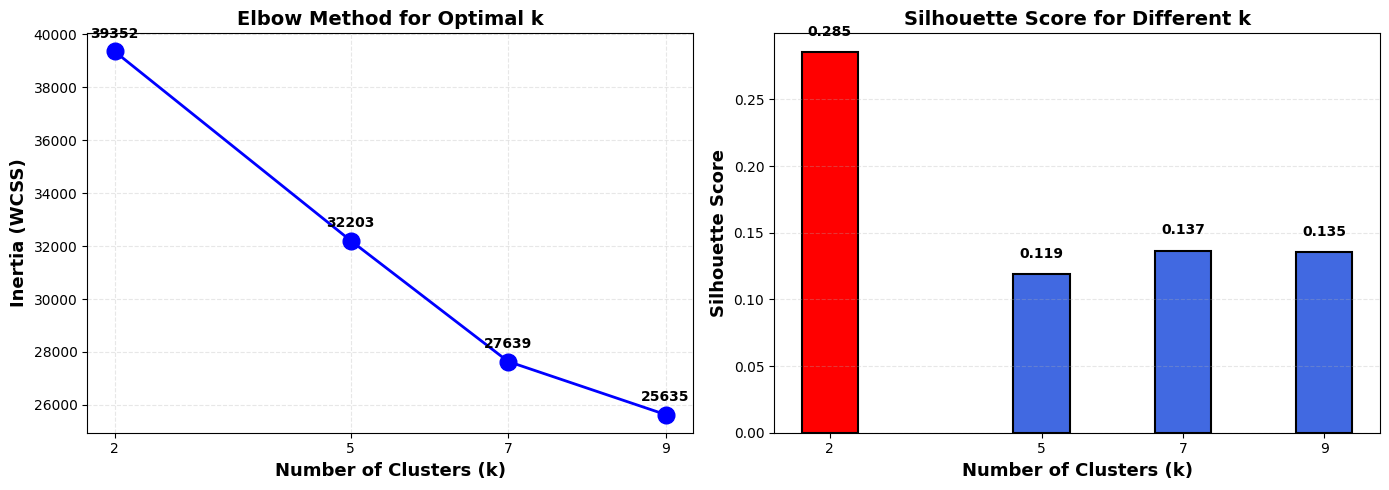

Visualization saved as 'clustering_evaluation.png'


In [10]:
"""
VISUALIZATION: ELBOW METHOD AND SILHOUETTE SCORE
"""

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Elbow Method (Inertia)
ax1 = axes[0]
ax1.plot(results['k'], results['inertia'], 'bo-', linewidth=2, markersize=12)
ax1.set_xlabel('Number of Clusters (k)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Inertia (WCSS)', fontsize=13, fontweight='bold')
ax1.set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xticks(results['k'])

# Annotate points
for k, inertia in zip(results['k'], results['inertia']):
    ax1.annotate(f'{inertia:.0f}', 
                xy=(k, inertia), 
                xytext=(0, 10), 
                textcoords='offset points',
                ha='center',
                fontsize=10,
                fontweight='bold')

# Plot 2: Silhouette Score
ax2 = axes[1]
colors = ['red' if s == max(results['silhouette']) else 'royalblue' 
          for s in results['silhouette']]
ax2.bar(results['k'], results['silhouette'], color=colors, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Number of Clusters (k)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Silhouette Score', fontsize=13, fontweight='bold')
ax2.set_title('Silhouette Score for Different k', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_xticks(results['k'])

# Annotate bars
for k, sil in zip(results['k'], results['silhouette']):
    ax2.text(k, sil + 0.01, f'{sil:.3f}', 
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('clustering_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'clustering_evaluation.png'")


In [11]:
# %%
"""
ELBOW POINT ANALYSIS
"""

print("\n" + "="*80)
print("ELBOW METHOD ANALYSIS")
print("="*80)

# Calculate rate of decrease in inertia
inertia_decrease = []
for i in range(len(results['inertia']) - 1):
    decrease = results['inertia'][i] - results['inertia'][i+1]
    decrease_pct = (decrease / results['inertia'][i]) * 100
    inertia_decrease.append((results['k'][i], results['k'][i+1], decrease, decrease_pct))

print("\nRate of Inertia Decrease:")
print("-" * 80)
print(f"{'From k':>8} {'To k':>6} {'Absolute Decrease':>20} {'Percentage Decrease':>22}")
print("-" * 80)
for k1, k2, decrease, decrease_pct in inertia_decrease:
    print(f"{k1:>8} {k2:>6} {decrease:>20.2f} {decrease_pct:>21.2f}%")

# Find the elbow using the elbow method heuristic
# The elbow is where the rate of decrease slows down significantly
decrease_rates = [d[3] for d in inertia_decrease]
if len(decrease_rates) > 1:
    # Calculate second derivative (rate of change of decrease rate)
    rate_changes = [decrease_rates[i] - decrease_rates[i+1] for i in range(len(decrease_rates)-1)]
    elbow_idx = rate_changes.index(max(rate_changes))
    elbow_k = results['k'][elbow_idx + 1]  # +1 because we're looking at transitions
    
    print(f"\n{'='*80}")
    print(f"ELBOW POINT DETECTED: k = {elbow_k}")
    print(f"{'='*80}")
    print(f"At k={elbow_k}, the rate of inertia decrease begins to plateau significantly.")
    print(f"Beyond this point, adding more clusters provides diminishing returns.")
    print(f"{'='*80}\n")


ELBOW METHOD ANALYSIS

Rate of Inertia Decrease:
--------------------------------------------------------------------------------
  From k   To k    Absolute Decrease    Percentage Decrease
--------------------------------------------------------------------------------
       2      5              7148.81                 18.17%
       5      7              4564.72                 14.17%
       7      9              2004.00                  7.25%

ELBOW POINT DETECTED: k = 7
At k=7, the rate of inertia decrease begins to plateau significantly.
Beyond this point, adding more clusters provides diminishing returns.



In [12]:
"""
DETERMINE OPTIMAL NUMBER OF CLUSTERS
"""

# Find the k with highest silhouette score
optimal_k_idx = np.argmax(results['silhouette'])
optimal_k = results['k'][optimal_k_idx]

print("\n" + "="*80)
print("OPTIMAL NUMBER OF CLUSTERS")
print("="*80)
print(f"Based on Silhouette Score: k = {optimal_k}")
print(f"Silhouette Score: {results['silhouette'][optimal_k_idx]:.4f}")
print(f"Inertia: {results['inertia'][optimal_k_idx]:.2f}")
print(f"Iterations to Convergence: {results['n_iters'][optimal_k_idx]}")
print("="*80)

# Use the optimal model for further analysis
optimal_model = results['model'][optimal_k_idx]
optimal_labels = results['labels'][optimal_k_idx]



OPTIMAL NUMBER OF CLUSTERS
Based on Silhouette Score: k = 2
Silhouette Score: 0.2852
Inertia: 39352.10
Iterations to Convergence: 6


In [13]:
# Add cluster labels to the original dataframe
df_clustered = df.copy()
df_clustered['Cluster'] = optimal_labels

print(f"\nCluster Distribution for k={optimal_k}:")
print("-"*60)
cluster_dist = df_clustered['Cluster'].value_counts().sort_index()
for cluster_id, count in cluster_dist.items():
    percentage = (count / len(df_clustered)) * 100
    print(f"Cluster {cluster_id}: {count} customers ({percentage:.1f}%)")



Cluster Distribution for k=2:
------------------------------------------------------------
Cluster 0: 878 customers (39.9%)
Cluster 1: 1320 customers (60.1%)



DIMENSIONALITY REDUCTION FOR VISUALIZATION

PCA Explained Variance:
  • PC1 explains 32.41% of variance
  • PC2 explains 8.60% of variance
  • Total: 41.01% of variance captured


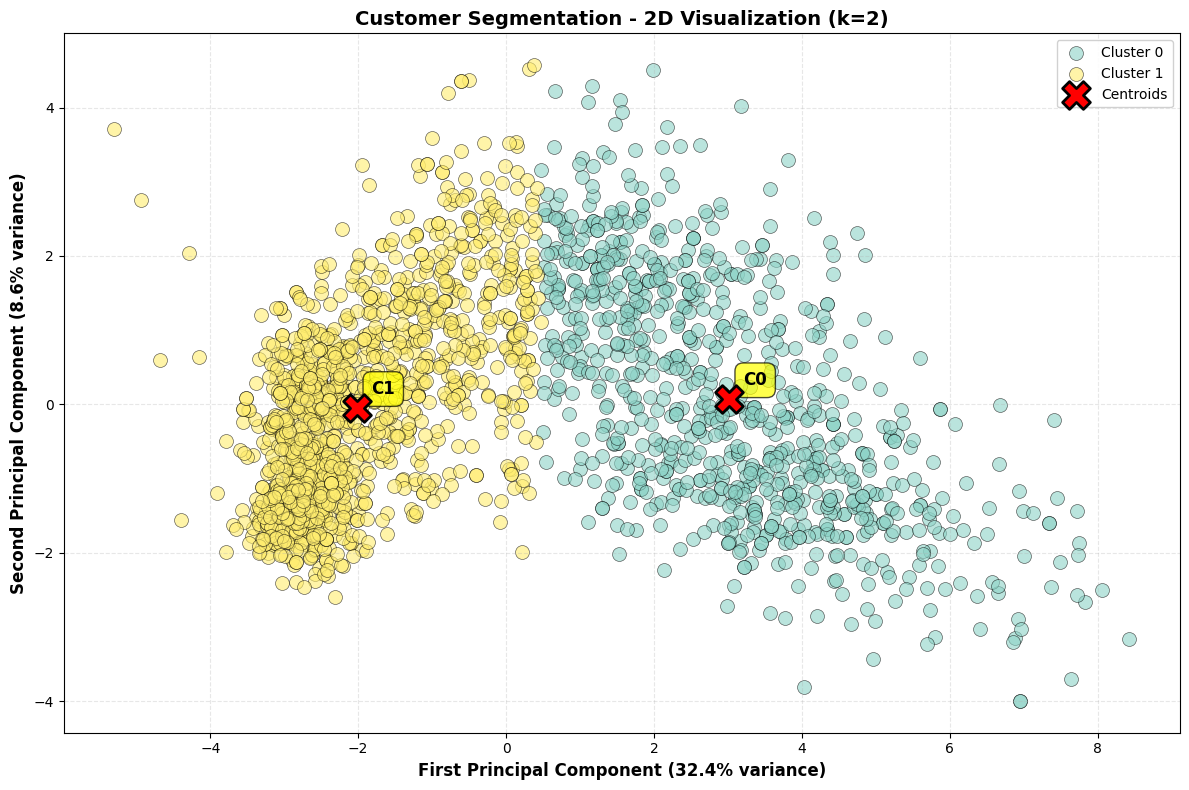


Visualization saved as 'cluster_visualization_2d.png'


In [16]:
# %%
"""
PCA VISUALIZATION - 2D CLUSTER VISUALIZATION
"""

print("\n" + "="*80)
print("DIMENSIONALITY REDUCTION FOR VISUALIZATION")
print("="*80)

# Apply PCA to reduce to 2 dimensions for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\nPCA Explained Variance:")
print(f"  • PC1 explains {pca.explained_variance_ratio_[0]*100:.2f}% of variance")
print(f"  • PC2 explains {pca.explained_variance_ratio_[1]*100:.2f}% of variance")
print(f"  • Total: {sum(pca.explained_variance_ratio_)*100:.2f}% of variance captured")

# Create visualization
plt.figure(figsize=(12, 8))

# Define colors for clusters
colors = plt.cm.Set3(np.linspace(0, 1, optimal_k))

# Plot each cluster
for cluster_id in range(optimal_k):
    cluster_points = X_pca[optimal_labels == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                c=[colors[cluster_id]], 
                label=f'Cluster {cluster_id}',
                alpha=0.6, 
                edgecolors='black',
                linewidth=0.5,
                s=100)

# Plot centroids in 2D space
centroids_pca = pca.transform(optimal_model.centroids)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='red', 
            marker='X', 
            s=400, 
            edgecolors='black',
            linewidth=2,
            label='Centroids',
            zorder=10)

# Add centroid labels
for i, centroid in enumerate(centroids_pca):
    plt.annotate(f'C{i}', 
                xy=centroid, 
                xytext=(10, 10),
                textcoords='offset points',
                fontsize=12,
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', 
           fontsize=12, fontweight='bold')
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', 
           fontsize=12, fontweight='bold')
plt.title(f'Customer Segmentation - 2D Visualization (k={optimal_k})', 
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('cluster_visualization_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'cluster_visualization_2d.png'")
print("="*80)


In [17]:
"""
CLUSTER PROFILES - KEY STATISTICS
"""

# Calculate cluster statistics for key features
key_features = ['Age', 'Income', 'Total Spending', 'Recency']

# Make sure these features exist in the dataframe
available_features = [f for f in key_features if f in df_clustered.columns]

print(f"\n{'='*80}")
print(f"CLUSTER PROFILES (k={optimal_k})")
print(f"{'='*80}\n")

cluster_summary = df_clustered.groupby('Cluster')[available_features].agg(['mean', 'std'])
print(cluster_summary.round(2))



CLUSTER PROFILES (k=2)

           Age           Income           Total Spending         Recency  \
          mean    std      mean       std           mean     std    mean   
Cluster                                                                    
0        58.05  12.21  71308.80  11871.23        1241.72  424.86   49.37   
1        54.82  11.17  38518.66  13861.72         184.71  192.99   48.87   

                
           std  
Cluster         
0        28.88  
1        28.98  


In [18]:
"""
DETAILED CLUSTER ANALYSIS
"""

print(f"\n\n{'='*80}")
print(f"DETAILED CLUSTER CHARACTERISTICS")
print(f"{'='*80}")

for cluster_id in range(optimal_k):
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster_id]
    n_customers = len(cluster_data)
    
    print(f"\n{'─'*80}")
    print(f"CLUSTER {cluster_id}: {n_customers} customers ({n_customers/len(df)*100:.1f}%)")
    print(f"{'─'*80}")
    
    # Demographics
    if 'Age' in cluster_data.columns:
        print(f"  Age: {cluster_data['Age'].mean():.1f} ± {cluster_data['Age'].std():.1f} years")
    
    if 'Income' in cluster_data.columns:
        print(f"  Income: ${cluster_data['Income'].mean():,.0f} ± ${cluster_data['Income'].std():,.0f}")
    
    # Spending behavior
    if 'Total Spending' in cluster_data.columns:
        print(f"  Total Spending: ${cluster_data['Total Spending'].mean():,.0f} ± ${cluster_data['Total Spending'].std():,.0f}")
    
    if 'Recency' in cluster_data.columns:
        print(f"  Recency: {cluster_data['Recency'].mean():.1f} ± {cluster_data['Recency'].std():.1f} days")
    
    # Spending by category
    print(f"\n  Product Category Spending:")
    spending_cols = ['MntWines', 'MntMeatProducts', 'MntFishProducts', 
                     'MntSweetProducts', 'MntFruits', 'MntGoldProds']
    for col in spending_cols:
        if col in cluster_data.columns:
            avg_spend = cluster_data[col].mean()
            print(f"    • {col.replace('Mnt', '')}: ${avg_spend:.0f}")
    
    # Purchase channels
    print(f"\n  Purchase Channels (Average # of Purchases):")
    channel_cols = ['NumWebPurchases', 'NumStorePurchases', 'NumCatalogPurchases']
    for col in channel_cols:
        if col in cluster_data.columns:
            avg_purchases = cluster_data[col].mean()
            print(f"    • {col.replace('Num', '').replace('Purchases', '')}: {avg_purchases:.1f}")




DETAILED CLUSTER CHARACTERISTICS

────────────────────────────────────────────────────────────────────────────────
CLUSTER 0: 878 customers (39.9%)
────────────────────────────────────────────────────────────────────────────────
  Age: 58.1 ± 12.2 years
  Income: $71,309 ± $11,871
  Total Spending: $1,242 ± $425
  Recency: 49.4 ± 28.9 days

  Product Category Spending:
    • Wines: $615
    • MeatProducts: $358
    • FishProducts: $79
    • SweetProducts: $58
    • Fruits: $56
    • GoldProds: $76

  Purchase Channels (Average # of Purchases):
    • Web: 5.8
    • Store: 8.6
    • Catalog: 5.3

────────────────────────────────────────────────────────────────────────────────
CLUSTER 1: 1320 customers (60.1%)
────────────────────────────────────────────────────────────────────────────────
  Age: 54.8 ± 11.2 years
  Income: $38,519 ± $13,862
  Total Spending: $185 ± $193
  Recency: 48.9 ± 29.0 days

  Product Category Spending:
    • Wines: $101
    • MeatProducts: $37
    • FishProduct

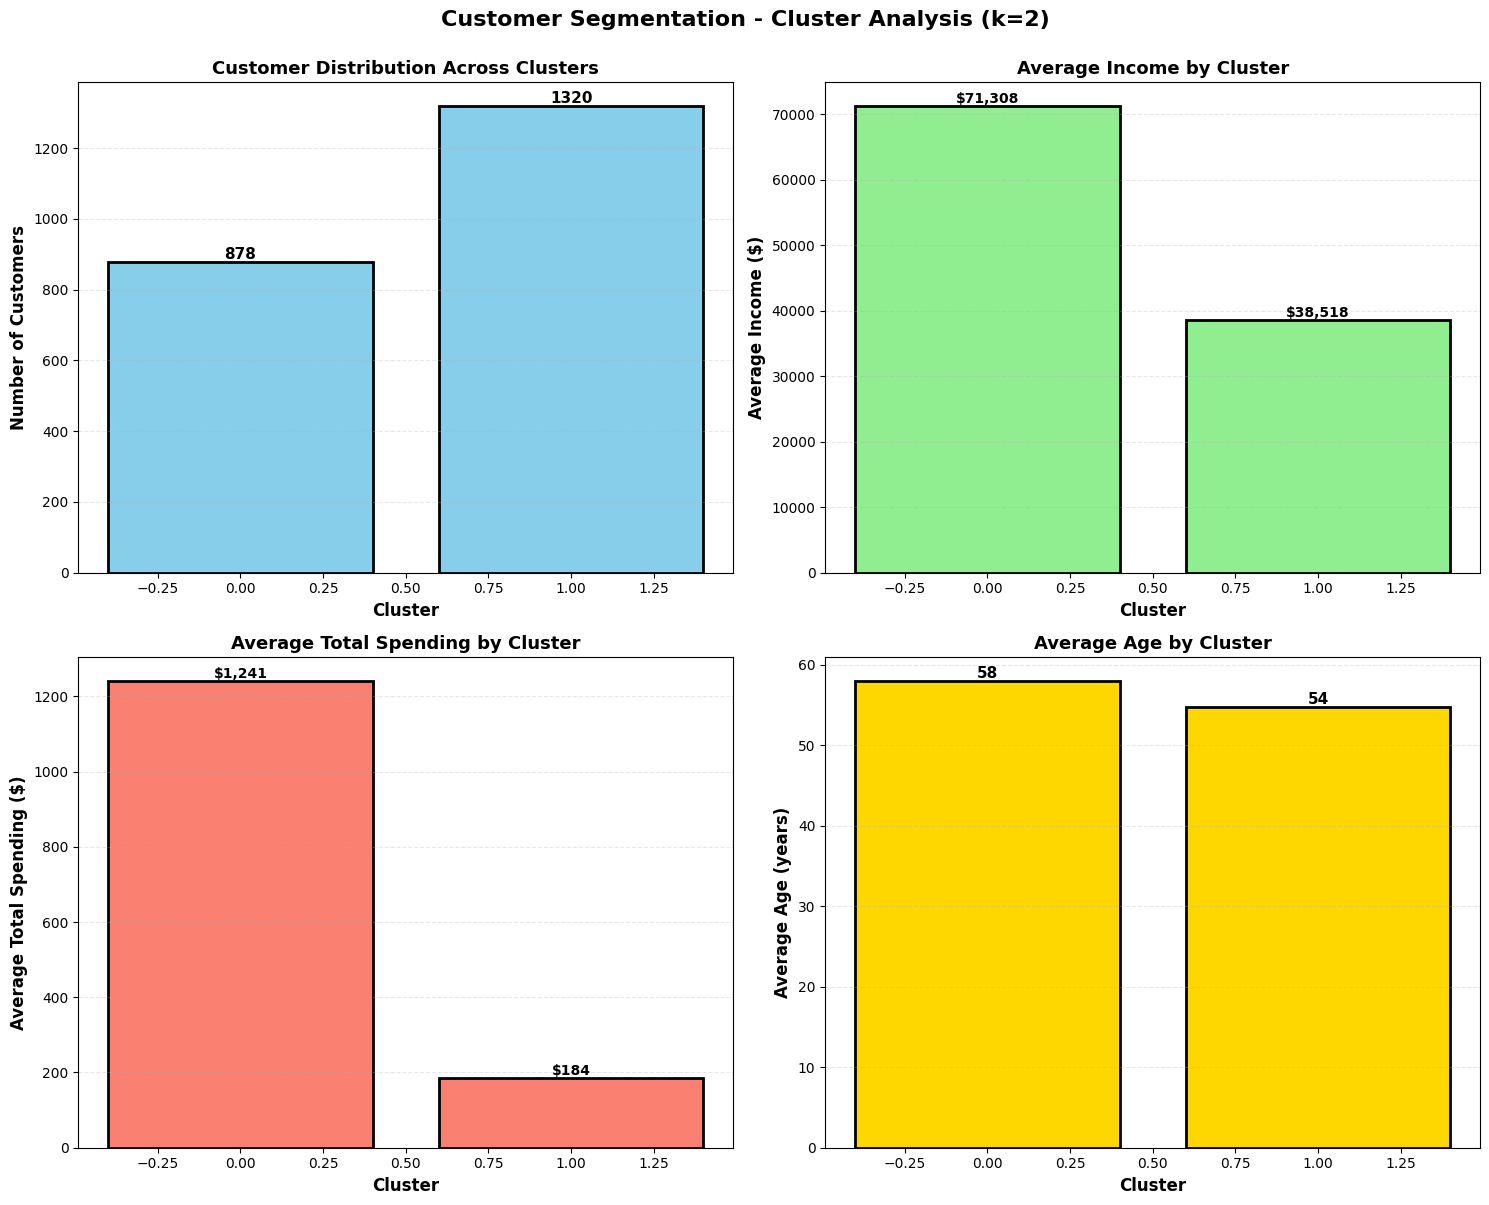

Visualization saved as 'cluster_profiles.png'


In [19]:
"""
VISUALIZATION: CLUSTER PROFILES
"""

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle(f'Customer Segmentation - Cluster Analysis (k={optimal_k})', 
             fontsize=16, fontweight='bold', y=1.00)

# Plot 1: Cluster sizes
ax1 = axes[0, 0]
cluster_counts = df_clustered['Cluster'].value_counts().sort_index()
bars1 = ax1.bar(cluster_counts.index, cluster_counts.values, 
                color='skyblue', edgecolor='black', linewidth=2)
ax1.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Customers', fontsize=12, fontweight='bold')
ax1.set_title('Customer Distribution Across Clusters', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 2: Average Income by Cluster
if 'Income' in df_clustered.columns:
    ax2 = axes[0, 1]
    income_by_cluster = df_clustered.groupby('Cluster')['Income'].mean()
    bars2 = ax2.bar(income_by_cluster.index, income_by_cluster.values, 
                    color='lightgreen', edgecolor='black', linewidth=2)
    ax2.set_xlabel('Cluster', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Average Income ($)', fontsize=12, fontweight='bold')
    ax2.set_title('Average Income by Cluster', fontsize=13, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'${int(height):,}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 3: Average Total Spending by Cluster
if 'Total Spending' in df_clustered.columns:
    ax3 = axes[1, 0]
    spending_by_cluster = df_clustered.groupby('Cluster')['Total Spending'].mean()
    bars3 = ax3.bar(spending_by_cluster.index, spending_by_cluster.values, 
                    color='salmon', edgecolor='black', linewidth=2)
    ax3.set_xlabel('Cluster', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Average Total Spending ($)', fontsize=12, fontweight='bold')
    ax3.set_title('Average Total Spending by Cluster', fontsize=13, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3, linestyle='--')
    
    for bar in bars3:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'${int(height):,}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 4: Average Age by Cluster
if 'Age' in df_clustered.columns:
    ax4 = axes[1, 1]
    age_by_cluster = df_clustered.groupby('Cluster')['Age'].mean()
    bars4 = ax4.bar(age_by_cluster.index, age_by_cluster.values, 
                    color='gold', edgecolor='black', linewidth=2)
    ax4.set_xlabel('Cluster', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Average Age (years)', fontsize=12, fontweight='bold')
    ax4.set_title('Average Age by Cluster', fontsize=13, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3, linestyle='--')
    
    for bar in bars4:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'cluster_profiles.png'")


In [20]:
"""
BUSINESS INTERPRETATION - CUSTOMER SEGMENTS
"""

print(f"\n\n{'='*80}")
print(f"BUSINESS INTERPRETATION & MARKETING RECOMMENDATIONS")
print(f"{'='*80}\n")

for cluster_id in range(optimal_k):
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster_id]
    
    print(f"{'─'*80}")
    print(f"SEGMENT {cluster_id}")
    print(f"{'─'*80}")
    
    # Calculate key metrics
    avg_income = cluster_data['Income'].mean() if 'Income' in cluster_data.columns else 0
    avg_spending = cluster_data['Total Spending'].mean() if 'Total Spending' in cluster_data.columns else 0
    avg_age = cluster_data['Age'].mean() if 'Age' in cluster_data.columns else 0
    avg_recency = cluster_data['Recency'].mean() if 'Recency' in cluster_data.columns else 0
    
    median_income = df['Income'].median() if 'Income' in df.columns else 0
    median_spending = df['Total Spending'].median() if 'Total Spending' in df.columns else 0
    
    # Determine segment type and strategy
    if avg_income > median_income * 1.2 and avg_spending > median_spending * 1.2:
        segment_name = "💎 PREMIUM HIGH-VALUE CUSTOMERS"
        description = "Wealthy customers with consistently high spending across all categories."
        strategy = """
        Marketing Strategy:
        • VIP loyalty program with exclusive benefits
        • Premium product recommendations
        • Personalized high-touch service
        • Priority access to new products and events
        """
    elif avg_spending > median_spending * 1.2:
        segment_name = "⭐ LOYAL BIG SPENDERS"
        description = "Regular high spenders regardless of income level."
        strategy = """
        Marketing Strategy:
        • Retention-focused loyalty rewards
        • Volume-based discounts
        • Regular engagement campaigns
        • Cross-selling opportunities
        """
    elif avg_income > median_income and avg_spending < median_spending * 0.8:
        segment_name = "🎯 POTENTIAL GROWTH SEGMENT"
        description = "High income but low spending - untapped potential."
        strategy = """
        Marketing Strategy:
        • Targeted awareness campaigns
        • Product sampling and trials
        • Personalized recommendations
        • Special introductory offers
        """
    else:
        segment_name = "💰 BUDGET-CONSCIOUS CUSTOMERS"
        description = "Price-sensitive customers seeking value."
        strategy = """
        Marketing Strategy:
        • Value-oriented promotions
        • Discount campaigns and deals
        • Bundle offers
        • Economy product line focus
        """
    
    print(f"\nSegment Name: {segment_name}")
    print(f"\nDescription: {description}")
    print(f"\nSize: {len(cluster_data)} customers ({len(cluster_data)/len(df)*100:.1f}% of customer base)")
    print(f"\nKey Characteristics:")
    print(f"  • Average Income: ${avg_income:,.0f}")
    print(f"  • Average Spending: ${avg_spending:,.0f}")
    print(f"  • Average Age: {avg_age:.0f} years")
    if avg_recency > 0:
        print(f"  • Last Purchase: {avg_recency:.0f} days ago")
    print(strategy)
    print()




BUSINESS INTERPRETATION & MARKETING RECOMMENDATIONS

────────────────────────────────────────────────────────────────────────────────
SEGMENT 0
────────────────────────────────────────────────────────────────────────────────

Segment Name: 💎 PREMIUM HIGH-VALUE CUSTOMERS

Description: Wealthy customers with consistently high spending across all categories.

Size: 878 customers (39.9% of customer base)

Key Characteristics:
  • Average Income: $71,309
  • Average Spending: $1,242
  • Average Age: 58 years
  • Last Purchase: 49 days ago

        Marketing Strategy:
        • VIP loyalty program with exclusive benefits
        • Premium product recommendations
        • Personalized high-touch service
        • Priority access to new products and events
        

────────────────────────────────────────────────────────────────────────────────
SEGMENT 1
────────────────────────────────────────────────────────────────────────────────

Segment Name: 💰 BUDGET-CONSCIOUS CUSTOMERS

Description

In [21]:
# Save clustered data
df_clustered.to_csv('customer_clusters.csv', index=False)
print("✓ Clustered data saved to 'customer_clusters.csv'")

# Save results summary
results_df.to_csv('clustering_results_summary.csv', index=False)
print("✓ Results summary saved to 'clustering_results_summary.csv'")


✓ Clustered data saved to 'customer_clusters.csv'
✓ Results summary saved to 'clustering_results_summary.csv'
